Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

plt.style.use('seaborn-v0_8-darkgrid')

print("Loading aligned macro and sentiment data...")
# Load the processed data from the ETL pipeline
df = pd.read_csv('../data/processed/macro_sentiment_aligned.csv', parse_dates=['observation_date'], index_col='observation_date')

y_inflation = df['Inflation_MoM']
x_sentiment = df['News Sentiment']

print("Data loaded successfully. Total months ready for modeling:", len(df))

Loading aligned macro and sentiment data...
Data loaded successfully. Total months ready for modeling: 555


HMM

In [2]:
print("\n--- Training Static HMMs ---")

# 2A: Baseline HMM (Inflation Only)
print("Training Baseline HMM...")
mod_hmm_base = sm.tsa.MarkovRegression(
    endog=y_inflation, 
    k_regimes=2, 
    switching_variance=True
)
res_hmm_base = mod_hmm_base.fit()

# 2B: HMM + Semantic Index
print("Training HMM + Semantic Index...")
mod_hmm_sem = sm.tsa.MarkovRegression(
    endog=y_inflation, 
    k_regimes=2, 
    exog=x_sentiment, 
    switching_variance=True
)
res_hmm_sem = mod_hmm_sem.fit()

print("Static HMM training complete.")


--- Training Static HMMs ---
Training Baseline HMM...
Training HMM + Semantic Index...
Static HMM training complete.


HMM Evaluation & Visualization


--- Comparing Static HMMs (Baseline vs. Semantic) ---
                    Model        AIC        BIC
           HMM (Baseline) -36.074510 -10.160702
HMM (with Semantic Index) -32.175466   2.376279


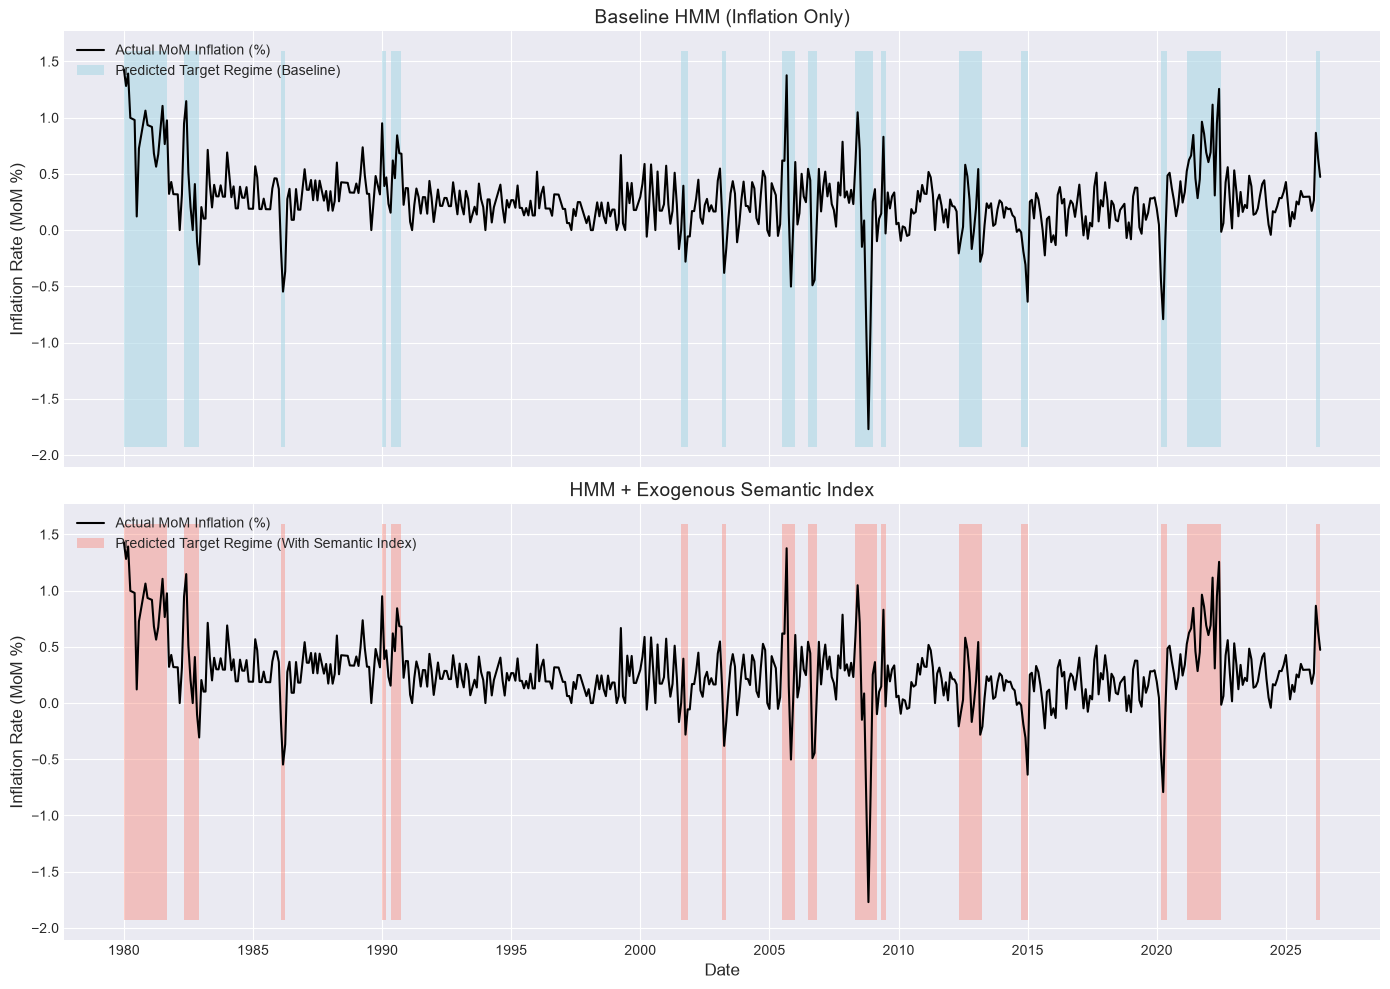

In [3]:
print("\n--- Comparing Static HMMs (Baseline vs. Semantic) ---")

# 1. Quantitative Comparison (AIC/BIC)
hmm_comparison = pd.DataFrame({
    'Model': ['HMM (Baseline)', 'HMM (with Semantic Index)'],
    'AIC': [res_hmm_base.aic, res_hmm_sem.aic],
    'BIC': [res_hmm_base.bic, res_hmm_sem.bic]
})
print(hmm_comparison.to_string(index=False))

# 2. Visual Comparison (Stacked Subplots)
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Extract probabilities for the high-volatility regime (Regime 1) from both models
prob_base = res_hmm_base.smoothed_marginal_probabilities[1]
prob_sem = res_hmm_sem.smoothed_marginal_probabilities[1]

# Top Plot: Baseline HMM
axes[0].plot(df.index, y_inflation, color='black', label='Actual MoM Inflation (%)', linewidth=1.5)
axes[0].fill_between(df.index, axes[0].get_ylim()[0], axes[0].get_ylim()[1], 
                where=(prob_base > 0.5), 
                facecolor='lightblue', alpha=0.6, label='Predicted Target Regime (Baseline)')
axes[0].set_title('Baseline HMM (Inflation Only)', fontsize=14)
axes[0].set_ylabel('Inflation Rate (MoM %)', fontsize=12)
axes[0].legend(loc='upper left')

# Bottom Plot: HMM + Semantic Index
axes[1].plot(df.index, y_inflation, color='black', label='Actual MoM Inflation (%)', linewidth=1.5)
axes[1].fill_between(df.index, axes[1].get_ylim()[0], axes[1].get_ylim()[1], 
                where=(prob_sem > 0.5), 
                facecolor='salmon', alpha=0.4, label='Predicted Target Regime (With Semantic Index)')
axes[1].set_title('HMM + Exogenous Semantic Index', fontsize=14)
axes[1].set_ylabel('Inflation Rate (MoM %)', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

AR HMM

In [4]:
print("\n--- Training Autoregressive HMMs ---")

# 3A: AR-HMM Baseline (Inflation + Momentum)
print("Training AR-HMM...")
mod_ar_base = sm.tsa.MarkovAutoregression(
    endog=y_inflation, 
    k_regimes=2, 
    order=1, 
    switching_variance=True
)
res_ar_base = mod_ar_base.fit()

# 3B: ARX-HMM (Momentum + Semantic Index)
print("Training ARX-HMM (Momentum + Semantic Index)...")
mod_ar_sem = sm.tsa.MarkovAutoregression(
    endog=y_inflation, 
    k_regimes=2, 
    order=1, 
    exog=x_sentiment, 
    switching_variance=True
)
res_ar_sem = mod_ar_sem.fit()

print("Autoregressive HMM training complete.")


--- Training Autoregressive HMMs ---
Training AR-HMM...
Training ARX-HMM (Momentum + Semantic Index)...
Autoregressive HMM training complete.


AR HMM Evaluation & Visualization


--- Comparing Autoregressive HMMs (Baseline vs. Semantic) ---
                       Model         AIC         BIC
           AR-HMM (Baseline) -154.159243 -119.621926
AR-HMM (with Semantic Index) -152.184983 -113.330500


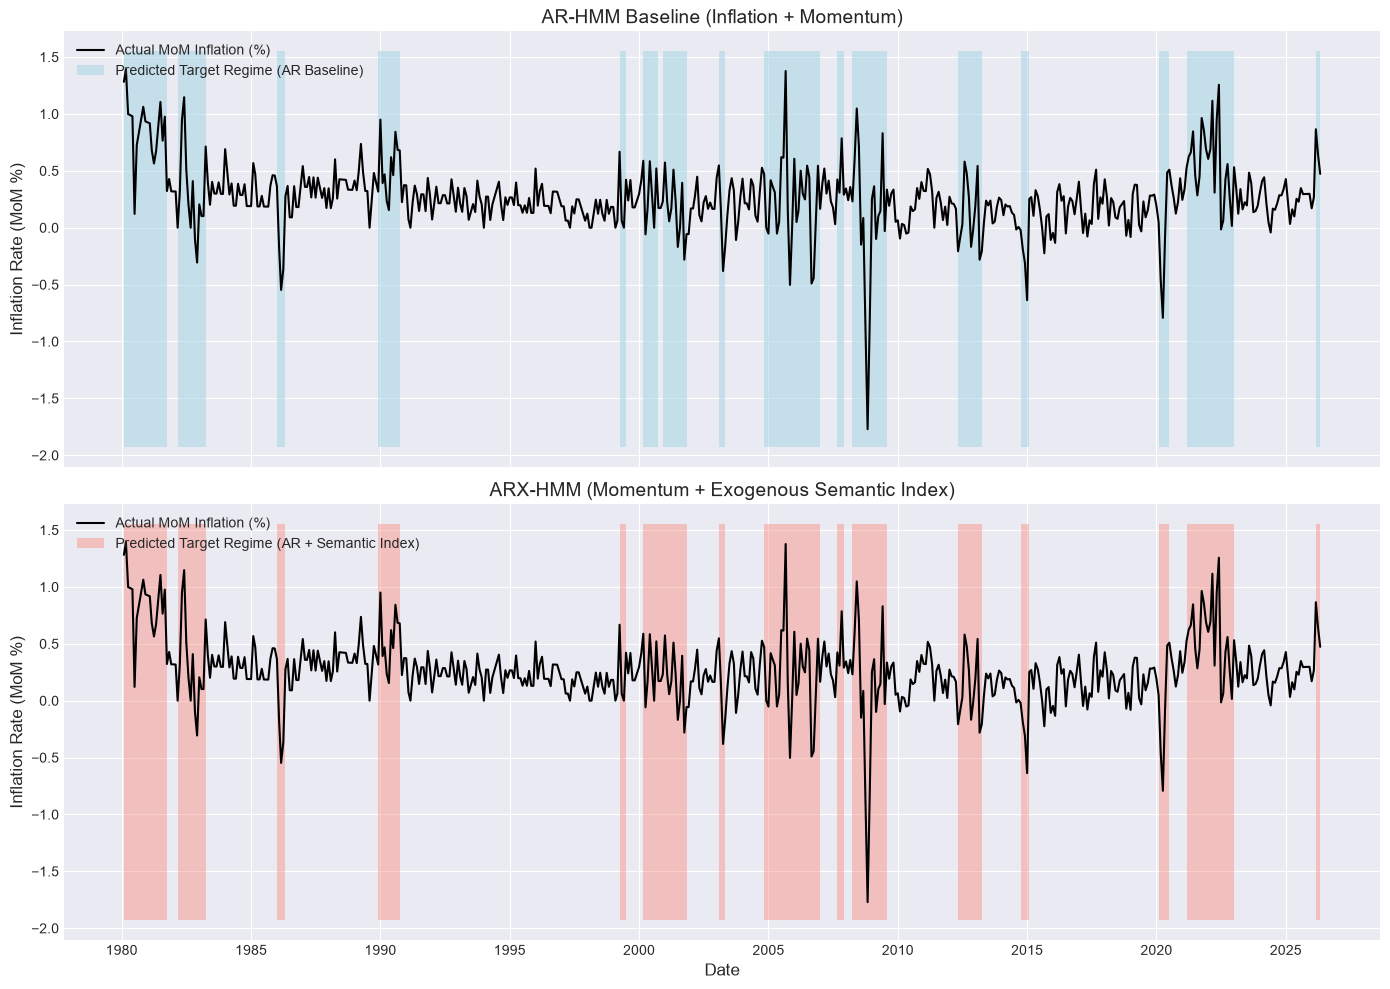

In [11]:
print("\n--- Comparing Autoregressive HMMs (Baseline vs. Semantic) ---")

# 1. Quantitative Comparison (AIC/BIC)
ar_comparison = pd.DataFrame({
    'Model': ['AR-HMM (Baseline)', 'AR-HMM (with Semantic Index)'],
    'AIC': [res_ar_base.aic, res_ar_sem.aic],
    'BIC': [res_ar_base.bic, res_ar_sem.bic]
})
print(ar_comparison.to_string(index=False))

# 2. Visual Comparison (Stacked Subplots)
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Extract probabilities for the high-volatility regime (Regime 1)
prob_ar_base = res_ar_base.smoothed_marginal_probabilities[1]
prob_ar_sem = res_ar_sem.smoothed_marginal_probabilities[1]

# IMPORTANT: Because AR(1) drops the first month to calculate momentum, 
# we must slice the index and the inflation data from 1 to the end to align the arrays perfectly.
aligned_index = df.index[1:]
aligned_inflation = y_inflation.iloc[1:]

# Top Plot: AR-HMM Baseline
axes[0].plot(aligned_index, aligned_inflation, color='black', label='Actual MoM Inflation (%)', linewidth=1.5)
axes[0].fill_between(aligned_index, axes[0].get_ylim()[0], axes[0].get_ylim()[1], 
                where=(prob_ar_base > 0.5), 
                facecolor='lightblue', alpha=0.6, label='Predicted Target Regime (AR Baseline)')
axes[0].set_title('AR-HMM Baseline (Inflation + Momentum)', fontsize=14)
axes[0].set_ylabel('Inflation Rate (MoM %)', fontsize=12)
axes[0].legend(loc='upper left')

# Bottom Plot: AR-HMM + Semantic Index
axes[1].plot(aligned_index, aligned_inflation, color='black', label='Actual MoM Inflation (%)', linewidth=1.5)
axes[1].fill_between(aligned_index, axes[1].get_ylim()[0], axes[1].get_ylim()[1], 
                where=(prob_ar_sem > 0.5), 
                facecolor='salmon', alpha=0.4, label='Predicted Target Regime (AR + Semantic Index)')
axes[1].set_title('ARX-HMM (Momentum + Exogenous Semantic Index)', fontsize=14)
axes[1].set_ylabel('Inflation Rate (MoM %)', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

Evaluation


 MODEL EVALUATION RESULTS (Lower AIC/BIC is Better)

         Model_Configuration         AIC         BIC
              HMM (Baseline)  -36.074510  -10.160702
   HMM (with Semantic Index)  -32.175466    2.376279
           AR-HMM (Baseline) -154.159243 -119.621926
AR-HMM (with Semantic Index) -152.184983 -113.330500


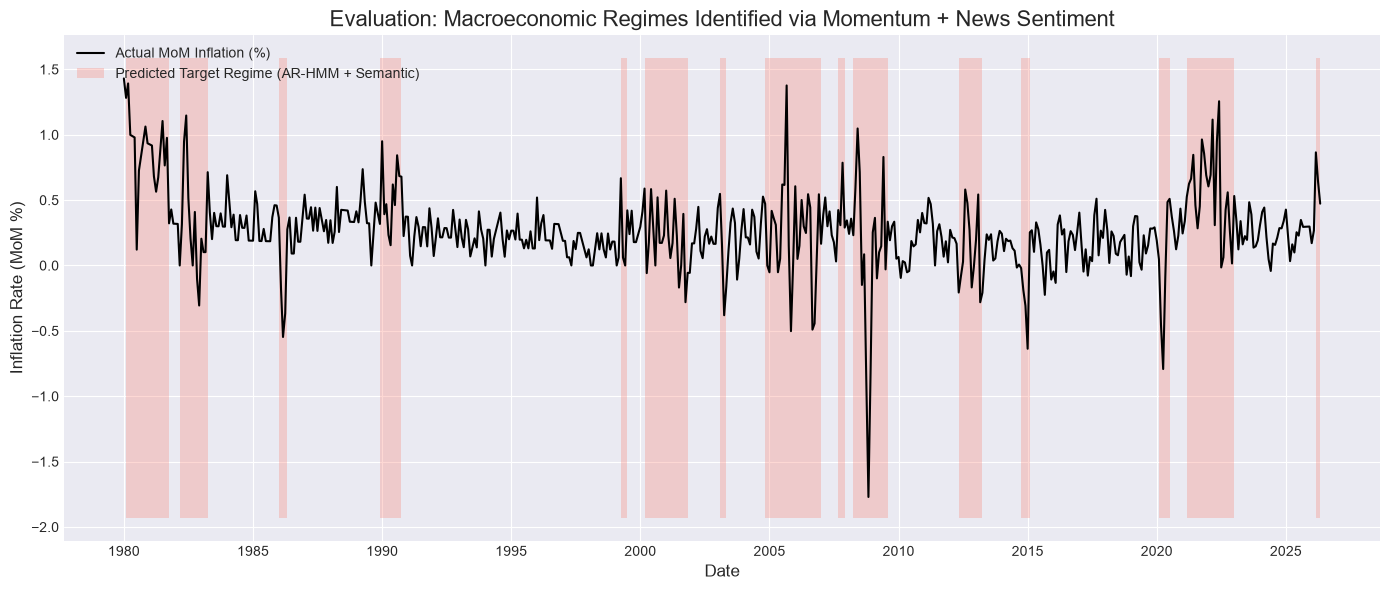

In [10]:
print("\n=======================================================")
print(" MODEL EVALUATION RESULTS (Lower AIC/BIC is Better)")
print("=======================================================\n")

# 4A: Quantitative Evaluation (AIC/BIC Comparison)
comparison_df = pd.DataFrame({
    'Model_Configuration': [
        'HMM (Baseline)', 
        'HMM (with Semantic Index)',
        'AR-HMM (Baseline)', 
        'AR-HMM (with Semantic Index)'
    ],
    'AIC': [res_hmm_base.aic, res_hmm_sem.aic, res_ar_base.aic, res_ar_sem.aic],
    'BIC': [res_hmm_base.bic, res_hmm_sem.bic, res_ar_base.bic, res_ar_sem.bic]
})

print(comparison_df.to_string(index=False))

# 4B: Visual Evaluation (Plotting the AR-HMM with Semantic Index)
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, y_inflation, color='black', label='Actual MoM Inflation (%)', linewidth=1.5)

# Extracting the high-volatility regime probabilities from the final ARX-HMM model
regime_1_probs = res_ar_sem.smoothed_marginal_probabilities[1]

# Slice the index from 1 to the end (df.index[1:]) to account for the 1-month AR lag
aligned_index = df.index[1:]

ax.fill_between(aligned_index, ax.get_ylim()[0], ax.get_ylim()[1], 
                where=(regime_1_probs > 0.5), 
                facecolor='salmon', alpha=0.3, label='Predicted Target Regime (AR-HMM + Semantic)')

plt.title('Evaluation: Macroeconomic Regimes Identified via Momentum + News Sentiment', fontsize=16)
plt.ylabel('Inflation Rate (MoM %)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()